In [1]:
# 多变量时序预测（案例）：SimpleRNN / LSTM / GRU — 空气污染预测
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # 本笔记全程使用 CPU；须在任何 import tensorflow 之前执行
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# 1. 加载数据
df = pd.read_csv('LSTM-Multivariate_pollution.csv', parse_dates=['date'])
df.set_index('date', inplace=True)

print("数据集形状:", df.shape)
print("\n数据前5行:")
print(df.head())
print("\n数据信息:")
print(df.info())
print("\n统计描述:")
print(df.describe())

数据集形状: (43800, 8)

数据前5行:
                     pollution  dew  temp   press wnd_dir  wnd_spd  snow  rain
date                                                                          
2010-01-02 00:00:00      129.0  -16  -4.0  1020.0      SE     1.79     0     0
2010-01-02 01:00:00      148.0  -15  -4.0  1020.0      SE     2.68     0     0
2010-01-02 02:00:00      159.0  -11  -5.0  1021.0      SE     3.57     0     0
2010-01-02 03:00:00      181.0   -7  -5.0  1022.0      SE     5.36     1     0
2010-01-02 04:00:00      138.0   -7  -5.0  1022.0      SE     6.25     2     0

数据信息:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  43800 non-null  float64
 1   dew        43800 non-null  int64  
 2   temp       43800 non-null  float64
 3   press      43800 non-null  float64
 4   wnd_dir    43800 non-null 

In [2]:
# 2. 数据预处理
# 检查缺失值
print("缺失值统计:")
print(df.isnull().sum())

# 处理缺失值 - 插值填充
df = df.interpolate(method='time')

# 对wnd_dir进行编码
le = LabelEncoder()
df['wnd_dir'] = le.fit_transform(df['wnd_dir'].astype(str))

print("\n处理后数据形状:", df.shape)
print("\n各列数据类型:")
print(df.dtypes)

缺失值统计:
pollution    0
dew          0
temp         0
press        0
wnd_dir      0
wnd_spd      0
snow         0
rain         0
dtype: int64

处理后数据形状: (43800, 8)

各列数据类型:
pollution    float64
dew            int64
temp         float64
press        float64
wnd_dir        int64
wnd_spd      float64
snow           int64
rain           int64
dtype: object


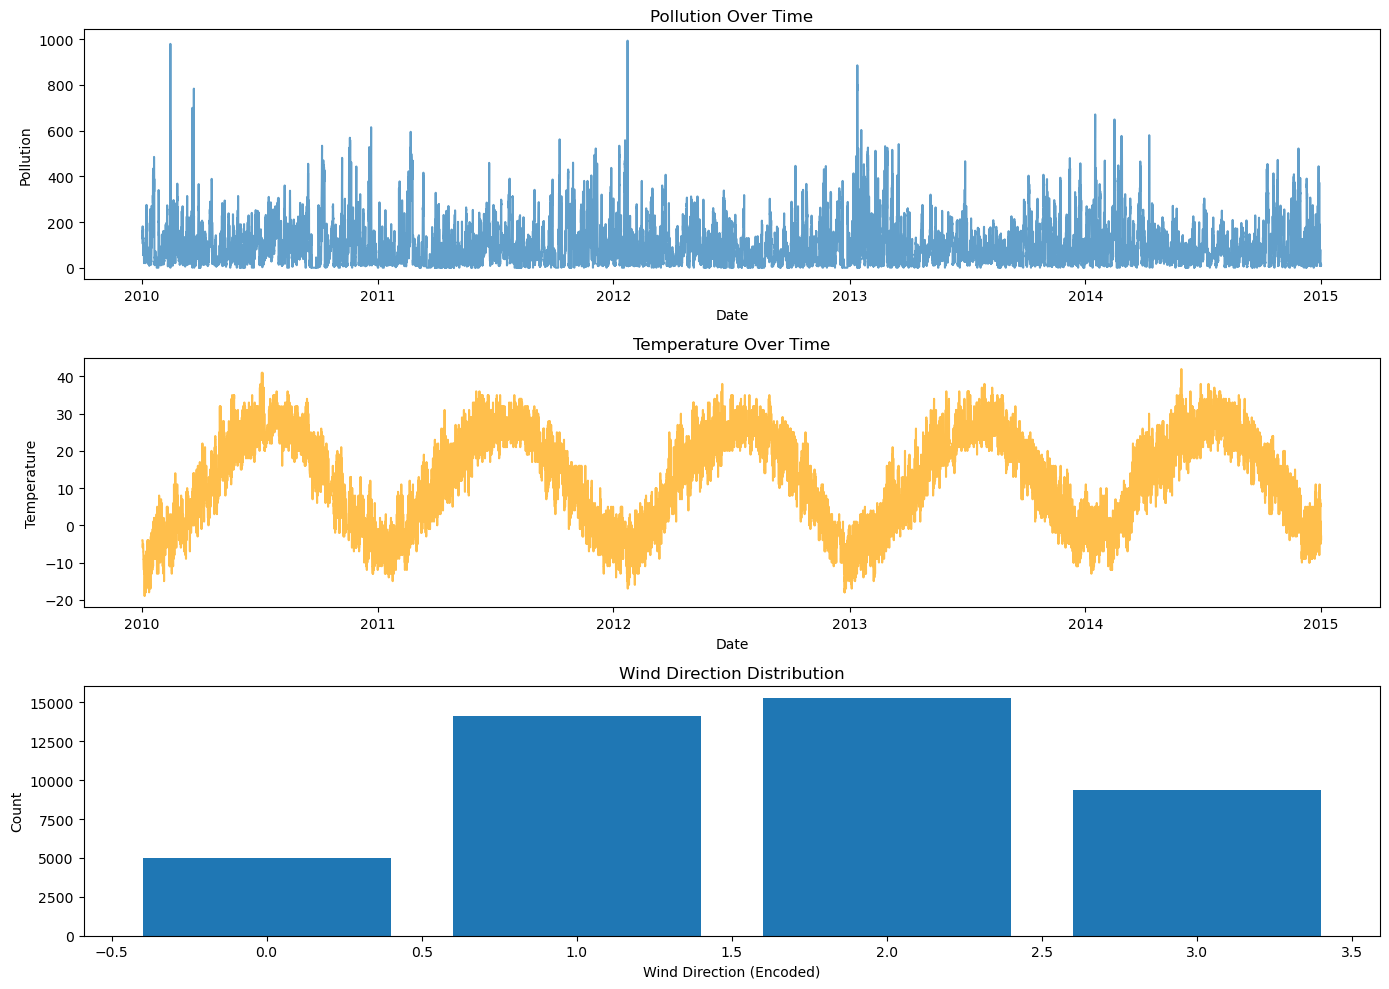

可视化已保存


In [3]:
# 3. 数据可视化
from matplotlib import pyplot as plt
from matplotlib import font_manager, rcParams


def setup_chinese_font():
    candidates = [
        "Noto Sans CJK SC",
        "Noto Sans CJK",
        "Source Han Sans SC",
        "WenQuanYi Zen Hei",
        "SimHei",
        "Microsoft YaHei",
        "PingFang SC",
        "Arial Unicode MS",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            rcParams["font.sans-serif"] = [font_name]
            break
    rcParams["axes.unicode_minus"] = False


setup_chinese_font()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 污染值时间序列
axes[0].plot(df["pollution"], alpha=0.7)
axes[0].set_title("污染浓度随时间变化")
axes[0].set_xlabel("时间")
axes[0].set_ylabel("污染值")

# 温度时间序列
axes[1].plot(df["temp"], alpha=0.7, color="orange")
axes[1].set_title("温度随时间变化")
axes[1].set_xlabel("时间")
axes[1].set_ylabel("温度")

# 风向分布
wind_counts = df["wnd_dir"].value_counts()
axes[2].bar(wind_counts.index, wind_counts.values)
axes[2].set_title("风向分布")
axes[2].set_xlabel("风向（编码后）")
axes[2].set_ylabel("出现次数")

plt.tight_layout()
plt.savefig("data_visualization.png", dpi=150)
plt.show()
print("可视化已保存：data_visualization.png")

In [4]:
# 4. 创建序列数据 - 用于 RNN / LSTM / GRU（同一 (samples, T, features) 张量）
def create_sequences(data, seq_length, target_col_index):
    """创建 (X, y) 序列：X 为滑动窗口，适用于 SimpleRNN / LSTM / GRU。"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)])
        y.append(data[i + seq_length, target_col_index])
    return np.array(X), np.array(y)

# 数据归一化
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

# 设置参数
seq_length = 168  # 使用一周的数据 (7天 * 24小时)
target_col_index = 0  # pollution列的索引

# 创建序列
X, y = create_sequences(scaled_data, seq_length, target_col_index)
print("特征数据形状:", X.shape)  # (samples, seq_length, features)
print("目标数据形状:", y.shape)  # (samples,)

# 划分训练集和测试集 (80% 训练, 20% 测试)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"\n训练集: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"测试集: X_test {X_test.shape}, y_test {y_test.shape}")

特征数据形状: (43632, 168, 8)
目标数据形状: (43632,)

训练集: X_train (34905, 168, 8), y_train (34905,)
测试集: X_test (8727, 168, 8), y_test (8727,)


## 案例教学：同一任务下的 RNN、LSTM 与 GRU

本笔记本用 **北京多变量空气污染时序数据**（`LSTM-Multivariate_pollution.csv`）做统一案例：用过去 **168 小时（一周）** 的气象与污染物等特征，预测下一时刻的污染浓度。

| 模型 | 核心思想（在本案例中的角色） |
|------|------------------------------|
| **Vanilla RNN（SimpleRNN）** | 用同一套循环权重把「上一时刻隐状态 + 当前输入」压成新隐状态，参数少、实现简单，但长序列上易出现 **梯度消失/爆炸**，对「一周前」的信息保留较弱。 |
| **LSTM** | 引入 **细胞状态** 与 **三门一候选**，显式控制「记什么、忘什么、输出什么」，更适合捕捉周内早晚高峰、周期性等长依赖。 |
| **GRU** | 用 **重置门 + 更新门**（比 LSTM 少一个门与一条状态）近似 LSTM 的筛选能力，参数更少、训练往往更快，效果常介于 RNN 与 LSTM 之间。 |

下面三节按 **LSTM →（对照）RNN →（对照）GRU** 搭建结构相同或相近的网络（双层循环 + Dropout + 全连接头），便于在同一划分与指标下比较。


### LSTM：细胞状态与四个门（教学要点）

每个时间步 \(t\) 读入当前特征向量 \(x_t\)，并与上一时刻隐状态 \(h_{t-1}\) 一起更新 **细胞状态** \(c_t\) 与 **隐状态** \(h_t\)。Keras 将四段线性结果拼成一块再拆开，顺序为 **i, f, c, o**（与下方代码 `np.split(..., 4)` 一致）。

**步骤 1 — 线性预激活（四段）**  
\[
[z_i, z_f, z_c, z_o] = x_t W_x + h_{t-1} W_h + b
\]
（含可选的 recurrent bias；实现细节见 `7c` 代码格。）

**步骤 2 — 输入门、遗忘门、输出门（sigmoid，输出在 \((0,1)\)）**  
\[
i_t = \sigma(z_i),\quad f_t = \sigma(z_f),\quad o_t = \sigma(z_o)
\]
- **输入门 \(i_t\)**：控制「当前候选信息」有多少写入细胞。  
- **遗忘门 \(f_t\)**：控制上一刻细胞状态 \(c_{t-1}\) 保留多少（小时级气象突变时常靠它「忘掉」过时模式）。  
- **输出门 \(o_t\)**：控制从 \(c_t\) 读出多少到隐状态 \(h_t\)（供后续时刻与全连接头使用）。

**步骤 3 — 细胞候选（常称「cell gate / 候选细胞」，用 tanh）**  
\[
\tilde{c}_t = \tanh(z_c)
\]
这是**待写入**的新内容（未经门筛选的「提议」）。

**步骤 4 — 更新细胞状态（记忆主线）**  
\[
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
\]
先按 \(f_t\) 遗忘旧记忆，再按 \(i_t\) 掺入新候选；加法结构有利于 **长程梯度** 流动。

**步骤 5 — 更新隐状态（读出）**  
\[
h_t = o_t \odot \tanh(c_t)
\]
\(\tanh(c_t)\) 把细胞压缩到合理范围，\(o_t\) 再决定对外暴露多少。

**与本案例的联系**：污染浓度与风速、湿度等 **跨多天的滞后** 有关；LSTM 通过 \(f_t,i_t\) 在 \(c_t\) 上选择性累积或擦除信息，比 SimpleRNN 更稳地利用整段 168 小时窗口。运行后面的 **`7c` 格** 可把各门沿时间在第一层上 **可视化**，并与 Keras 输出数值校验。


In [5]:
# 5. 构建LSTM模型（强制 CPU）
# 说明：os.environ['CUDA_VISIBLE_DEVICES'] 只有在「本内核从未 import 过 tensorflow」时才会禁止 GPU。
# 若你曾先 import 过 tf 再改环境变量，仍会走 GPU:0。此时请 内核 → 重启 后从第一格顺序运行；或靠下面 set_visible_devices + device 双保险。
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

try:
    tf.config.set_visible_devices([], "GPU")
except Exception as e:
    print("提示: 若仍报 GPU 相关错误，请「重启内核」后从第 1 格重新运行。原始信息:", e)

# 设置随机种子以保证可重复性
np.random.seed(42)
tf.random.set_seed(42)

n_features = X_train.shape[2]

# 在 CPU:0 上建图，避免 LSTM 初始化时 Cast 落到 GPU
with tf.device("/CPU:0"):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_length, n_features)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

2026-04-28 18:04:32.649879: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 64)        │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# 6. 训练模型
import tensorflow as tf

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

with tf.device("/CPU:0"):
    history = model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=1,
    )

print("\n训练完成!")

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - loss: 0.0039 - mae: 0.0419 - val_loss: 0.0010 - val_mae: 0.0202
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - loss: 0.0015 - mae: 0.0245 - val_loss: 7.2650e-04 - val_mae: 0.0165
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - loss: 0.0012 - mae: 0.0212 - val_loss: 6.7661e-04 - val_mae: 0.0164
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - loss: 0.0011 - mae: 0.0194 - val_loss: 6.0474e-04 - val_mae: 0.0142
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - loss: 0.0010 - mae: 0.0184 - val_loss: 5.6293e-04 - val_mae: 0.0136
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 9.6358e-04 - mae: 0.0179 - val_loss: 5.5974e-04 - val_mae: 0.0134
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - loss: 9.3173e-04 - mae: 0.0175 - val_loss: 5.6674e-04 - val_mae: 0.0137
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - loss: 9.4165e-04 - mae: 0.0174 - val_loss: 5.7008e-04 - val_mae: 0.0142


### RNN（SimpleRNN）：案例中的「基线循环」

Vanilla RNN 每步只做 **一次压缩 + 激活**（Keras 默认 `tanh`）：

\[
h_t = \tanh(x_t W_x + h_{t-1} W_h + b)
\]

**与案例的关系**：\(h_t\) 同时承担「记忆」与「输出」，没有独立的细胞状态；当 \(T=168\) 较大时，早期 \(x\) 对 \(h_{168}\) 的影响经多次 \(\tanh\) 与乘法链后容易 **衰减**（梯度消失），因此同一结构上往往不如 LSTM/GRU。下面用 **与 LSTM 相同的输入形状与 Dense 头** 训练 SimpleRNN，便于直接对比误差曲线与测试集 MSE/MAE/R²。


In [7]:
# 6b. Vanilla RNN（Keras SimpleRNN）— 与 LSTM 相同输入形状与「双层循环 + 全连接头」
# 序列长度仍为 seq_length=168；时间维上为全序列 BPTT（Keras 默认沿整段序列反传）。
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

tf.random.set_seed(42)
np.random.seed(42)

with tf.device("/CPU:0"):
    model_rnn = Sequential(
        [
            SimpleRNN(64, return_sequences=True, input_shape=(seq_length, n_features)),
            Dropout(0.2),
            SimpleRNN(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation="relu"),
            Dense(1),
        ]
    )
    model_rnn.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_rnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 168, 64)        │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,321 (32.50 KB)

 Trainable params: 8,321 (32.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 6c. 训练 RNN（与 LSTM 相同的 batch、验证划分与早停，便于对照）
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stop_rnn = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

with tf.device("/CPU:0"):
    history_rnn = model_rnn.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop_rnn],
        verbose=1,
    )

print("\nRNN 训练完成!")

Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - loss: 0.0396 - mae: 0.1141 - val_loss: 0.0022 - val_mae: 0.0327
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0038 - mae: 0.0431 - val_loss: 0.0016 - val_mae: 0.0285
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.0026 - mae: 0.0352 - val_loss: 0.0012 - val_mae: 0.0241
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.0022 - mae: 0.0312 - val_loss: 0.0010 - val_mae: 0.0211
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 0.0019 - mae: 0.0286 - val_loss: 8.9041e-04 - val_mae: 0.0194
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0016 - mae: 0.0260 - val_loss: 8.1328e-04 - val_mae: 0.0187
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0015 - mae: 0.0247 - val_loss: 7.3576e-04 - val_mae: 0.0169
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.0014 - mae: 0.0232 - val_loss: 6.6433e-04 - val_mae: 0.0160
Epoch 9/30
491/491 ━━━━━

### GRU：两个门与一条隐状态（与 LSTM 对照）

GRU 没有独立的细胞状态 \(c_t\)，只用 **隐状态** \(h_t\)，通过 **重置门** \(r_t\) 与 **更新门** \(z_t\) 控制历史与当前输入的混合（Keras 默认实现与 Cho 2014 一致；以下符号与常见教材对应）。

**步骤 1 — 线性得到 \(z, r, h'\) 三段中的前两门与候选**  
先算更新门、重置门（sigmoid），再用重置门调制上一隐状态后与 \(x_t\) 一起得到候选 \(\tilde{h}_t\)（tanh）：

\[
z_t = \sigma(x_t W_{xz} + h_{t-1} W_{hz} + b_z),\quad
r_t = \sigma(x_t W_{xr} + h_{t-1} W_{hr} + b_r)
\]

\[
\tilde{h}_t = \tanh\big(x_t W_{xh} + (r_t \odot h_{t-1}) W_{hh} + b_h\big)
\]

**步骤 2 — 隐状态凸组合（更新门决定「留旧 vs 纳新」）**  
\[
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
\]

**与 LSTM 的直观对比**：LSTM 用 **遗忘/输入/输出** 三门 + **细胞状态加法轨道** 管理长记忆；GRU 用 **重置/更新** 两门把类似功能压进更少的参数里。下面在同一数据与网络深度上训练 `GRU`，与 LSTM、SimpleRNN 并列比较。


In [9]:
# 6d. GRU（Keras GRU）— 与 LSTM / RNN 相同的「双层循环 + 全连接头」
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

tf.random.set_seed(42)
np.random.seed(42)

with tf.device("/CPU:0"):
    model_gru = Sequential(
        [
            GRU(64, return_sequences=True, input_shape=(seq_length, n_features)),
            Dropout(0.2),
            GRU(32, return_sequences=False),
            Dropout(0.2),
            Dense(16, activation="relu"),
            Dense(1),
        ]
    )
    model_gru.compile(optimizer="adam", loss="mse", metrics=["mae"])

model_gru.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 168, 64)        │        14,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 168, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,161 (94.38 KB)

 Trainable params: 24,161 (94.38 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 7. 模型评估
import tensorflow as tf

# 在测试集上预测（保持在 CPU，与建模一致）
with tf.device("/CPU:0"):
    y_pred = model.predict(X_test, verbose=1)

# 反归一化：scaler 在全部特征列上拟合，仅预测了目标列，需用 0 填充其余列再 inverse_transform
n_pad = int(scaler.n_features_in_) - 1
y_pred_inv = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred), n_pad))], axis=1)
)[:, 0]

y_test_inv = scaler.inverse_transform(
    np.concatenate([y_test.reshape(-1, 1), np.zeros((len(y_test), n_pad))], axis=1)
)[:, 0]

# 计算评估指标
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print("=" * 50)
print("模型评估结果")
print("=" * 50)
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R²:   {r2:.4f}")

273/273 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
模型评估结果
MSE:  541.4547
RMSE: 23.2692
MAE:  12.3049
R²:   0.9383


In [11]:
# 6e. 训练 GRU（与 LSTM / RNN 相同的 batch、验证划分与早停）
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stop_gru = EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

with tf.device("/CPU:0"):
    history_gru = model_gru.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=64,
        validation_split=0.1,
        callbacks=[early_stop_gru],
        verbose=1,
    )

print("\nGRU 训练完成!")


Epoch 1/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - loss: 0.0056 - mae: 0.0476 - val_loss: 9.0957e-04 - val_mae: 0.0198
Epoch 2/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - loss: 0.0013 - mae: 0.0230 - val_loss: 6.9790e-04 - val_mae: 0.0168
Epoch 3/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - loss: 0.0011 - mae: 0.0199 - val_loss: 5.8923e-04 - val_mae: 0.0142
Epoch 4/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - loss: 9.7534e-04 - mae: 0.0184 - val_loss: 5.5326e-04 - val_mae: 0.0138
Epoch 5/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - loss: 9.4032e-04 - mae: 0.0178 - val_loss: 5.3387e-04 - val_mae: 0.0133
Epoch 6/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - loss: 8.9438e-04 - mae: 0.0172 - val_loss: 5.1481e-04 - val_mae: 0.0132
Epoch 7/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - loss: 8.6261e-04 - mae: 0.0167 - val_loss: 5.5405e-04 - val_mae: 0.0136
Epoch 8/30
491/491 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - loss: 8.5410e-04 - mae: 0.0167 - val_loss: 5.0524e-04 - val_

第一层 LSTM 显式前向 vs Keras 输出 max|diff| = 4.47e-08（应接近机器精度）


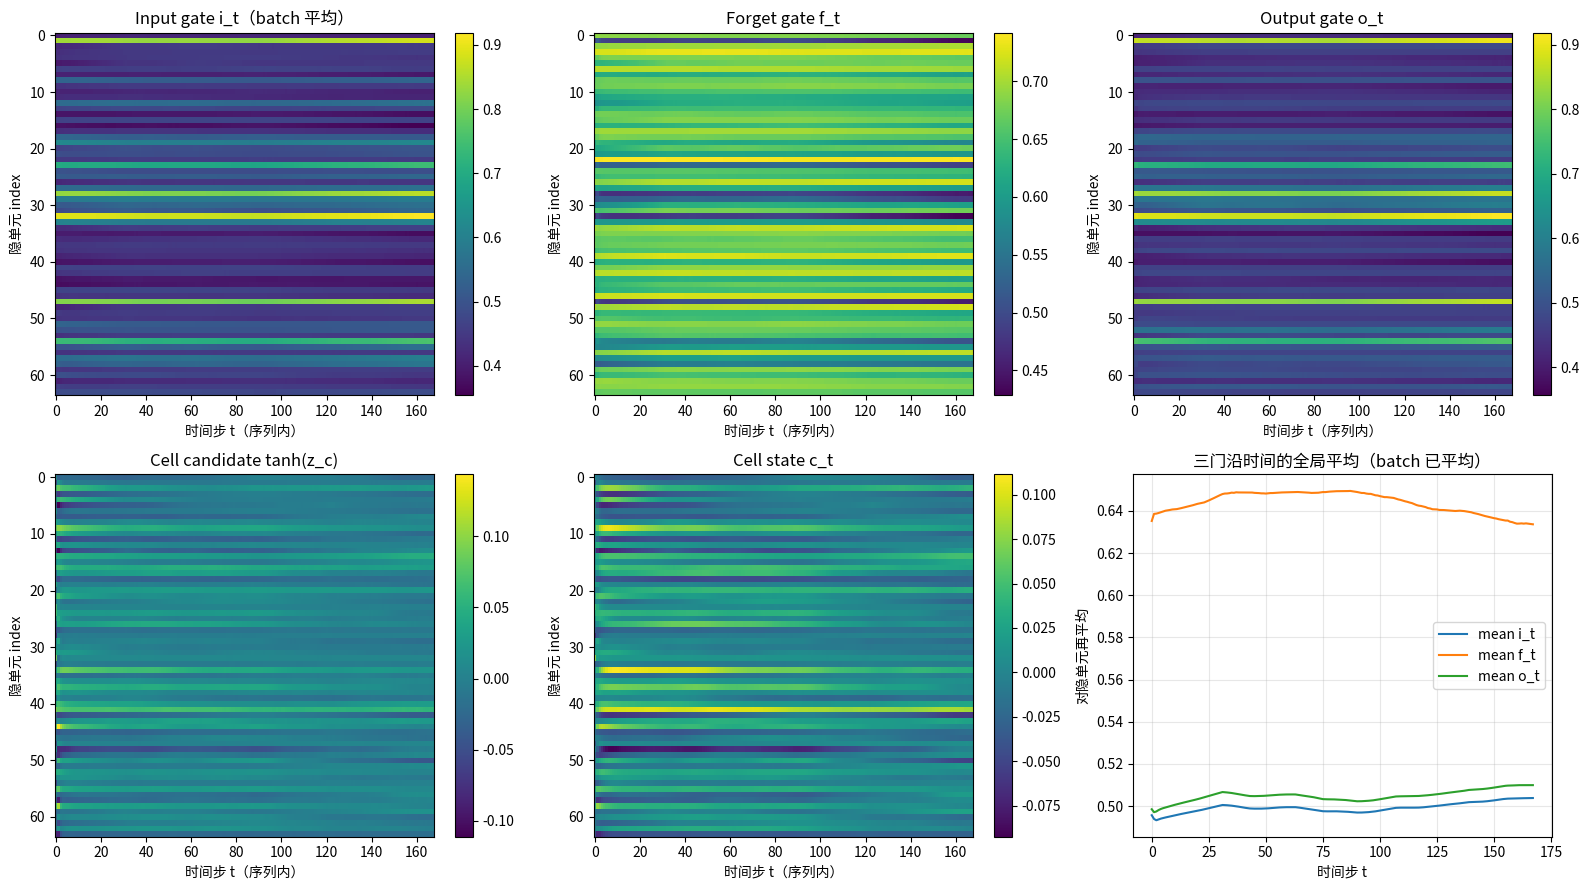

已保存 lstm_gates_visualization.png


In [36]:
# 7c. 第一层 LSTM：与上文「步骤 1–5」对应 — Input(i) / Forget(f) / Cell 候选 tanh(z_c) / Output(o) + Cell state
# tf.keras LSTM：kernel 最后一维按 i, f, c, o 四段；c 段经 tanh 为 cell candidate \tilde{c}_t。
import tensorflow as tf
from matplotlib import font_manager, rcParams
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 告诉 Matplotlib 你的字体文件在哪里
font_path = '/home/hxy/font.otf'
fm.fontManager.addfont(font_path)

# 2. 获取这个字体的正式名称（它可能叫 "Source Han Sans SC" 之类的）
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

# 3. 设置全局默认字体
plt.rcParams['font.sans-serif'] = [font_name] # 动态设置为你下载的字体名称
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

def setup_chinese_font():
    candidates = [
        "Noto Sans CJK SC",
        "Noto Sans CJK",
        "Source Han Sans SC",
        "WenQuanYi Zen Hei",
        "SimHei",
        "Microsoft YaHei",
        "PingFang SC",
        "Arial Unicode MS",
    ]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            rcParams["font.sans-serif"] = [font_name]
            break
    rcParams["axes.unicode_minus"] = False


setup_chinese_font()


def lstm_first_layer_gates(x_np, lstm_layer):
    wts = lstm_layer.get_weights()
    kernel, rec_kernel, bias = wts[0], wts[1], wts[2]
    recurrent_bias = wts[3] if len(wts) > 3 else np.zeros_like(bias)
    units = int(lstm_layer.units)
    x = np.asarray(x_np, dtype=np.float32)
    B, T, Fdim = x.shape
    h = np.zeros((B, units), np.float32)
    c = np.zeros((B, units), np.float32)
    Ig, Fg, Ctil, Og, Cc, Hh = [], [], [], [], [], []
    for t in range(T):
        z = x[:, t, :] @ kernel + h @ rec_kernel + bias + recurrent_bias
        zi, zf, zc, zo = np.split(z, 4, axis=-1)
        i = 1.0 / (1.0 + np.exp(-np.clip(zi, -30, 30)))
        f = 1.0 / (1.0 + np.exp(-np.clip(zf, -30, 30)))
        c_tilde = np.tanh(zc)
        o = 1.0 / (1.0 + np.exp(-np.clip(zo, -30, 30)))
        c = f * c + i * c_tilde
        h = o * np.tanh(c)
        Ig.append(i)
        Fg.append(f)
        Ctil.append(c_tilde)
        Og.append(o)
        Cc.append(c.copy())
        Hh.append(h.copy())
    to_btu = lambda L: np.stack(L, axis=1)
    return {
        "input_gate": to_btu(Ig),
        "forget_gate": to_btu(Fg),
        "cell_candidate": to_btu(Ctil),
        "output_gate": to_btu(Og),
        "cell_state": to_btu(Cc),
        "hidden": to_btu(Hh),
    }


lstm1 = model.layers[0]
n_demo = min(64, len(X_test))
x_demo = X_test[:n_demo].astype(np.float32)
G = lstm_first_layer_gates(x_demo, lstm1)

with tf.device("/CPU:0"):
    h_keras = lstm1(x_demo, training=False).numpy()
err = float(np.max(np.abs(G["hidden"] - h_keras)))
print(f"第一层 LSTM 显式前向 vs Keras 输出 max|diff| = {err:.2e}（应接近机器精度）")

mean = {k: v.mean(axis=0) for k, v in G.items()}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
titles = [
    ("input_gate", "Input gate i_t（batch 平均）"),
    ("forget_gate", "Forget gate f_t"),
    ("output_gate", "Output gate o_t"),
    ("cell_candidate", "Cell candidate tanh(z_c)"),
    ("cell_state", "Cell state c_t"),
]
for ax, (key, title) in zip(axes.flat[:5], titles):
    im = ax.imshow(mean[key].T, aspect="auto", cmap="viridis", interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("时间步 t（序列内）")
    ax.set_ylabel("隐单元 index")
    plt.colorbar(im, ax=ax, fraction=0.046)

T = mean["input_gate"].shape[0]
t_axis = np.arange(T)
axes.flat[5].plot(t_axis, mean["input_gate"].mean(axis=1), label="mean i_t")
axes.flat[5].plot(t_axis, mean["forget_gate"].mean(axis=1), label="mean f_t")
axes.flat[5].plot(t_axis, mean["output_gate"].mean(axis=1), label="mean o_t")
axes.flat[5].set_xlabel("时间步 t")
axes.flat[5].set_ylabel("对隐单元再平均")
axes.flat[5].set_title("三门沿时间的全局平均（batch 已平均）")
axes.flat[5].legend()
axes.flat[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_gates_visualization.png", dpi=150)
plt.show()
print("已保存 lstm_gates_visualization.png")


In [17]:
# 7b. RNN / GRU 测试集评估（反归一化与 LSTM 相同）及三模型指标对照
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lstm_mse, lstm_mae, lstm_r2 = mse, mae, r2

with tf.device("/CPU:0"):
    y_pred_rnn = model_rnn.predict(X_test, verbose=1)
    y_pred_gru = model_gru.predict(X_test, verbose=1)

y_pred_rnn_inv = scaler.inverse_transform(
    np.concatenate([y_pred_rnn, np.zeros((len(y_pred_rnn), n_pad))], axis=1)
)[:, 0]

y_pred_gru_inv = scaler.inverse_transform(
    np.concatenate([y_pred_gru, np.zeros((len(y_pred_gru), n_pad))], axis=1)
)[:, 0]

mse_rnn = mean_squared_error(y_test_inv, y_pred_rnn_inv)
rmse_rnn = float(np.sqrt(mse_rnn))
mae_rnn = mean_absolute_error(y_test_inv, y_pred_rnn_inv)
r2_rnn = r2_score(y_test_inv, y_pred_rnn_inv)

mse_gru = mean_squared_error(y_test_inv, y_pred_gru_inv)
rmse_gru = float(np.sqrt(mse_gru))
mae_gru = mean_absolute_error(y_test_inv, y_pred_gru_inv)
r2_gru = r2_score(y_test_inv, y_pred_gru_inv)

print("=" * 50)
print("RNN（SimpleRNN）测试集结果")
print("=" * 50)
print(f"MSE:  {mse_rnn:.4f}")
print(f"RMSE: {rmse_rnn:.4f}")
print(f"MAE:  {mae_rnn:.4f}")
print(f"R²:   {r2_rnn:.4f}")

print("=" * 50)
print("GRU 测试集结果")
print("=" * 50)
print(f"MSE:  {mse_gru:.4f}")
print(f"RMSE: {rmse_gru:.4f}")
print(f"MAE:  {mae_gru:.4f}")
print(f"R²:   {r2_gru:.4f}")

print("\n" + "=" * 50)
print("LSTM vs RNN vs GRU（同一测试集、同一反归一化）")
print("=" * 50)
print(f"{'':8} {'MSE':>12} {'MAE':>12} {'R²':>10}")
print(f"{'LSTM':8} {lstm_mse:12.4f} {lstm_mae:12.4f} {lstm_r2:10.4f}")
print(f"{'RNN':8} {mse_rnn:12.4f} {mae_rnn:12.4f} {r2_rnn:10.4f}")
print(f"{'GRU':8} {mse_gru:12.4f} {mae_gru:12.4f} {r2_gru:10.4f}")


273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
273/273 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
RNN（SimpleRNN）测试集结果
MSE:  573.1438
RMSE: 23.9404
MAE:  13.3843
R²:   0.9347
GRU 测试集结果
MSE:  528.7981
RMSE: 22.9956
MAE:  12.2503
R²:   0.9397

LSTM vs RNN vs GRU（同一测试集、同一反归一化）
                  MSE          MAE         R²
LSTM         541.4547      12.3049     0.9383
RNN          573.1438      13.3843     0.9347
GRU          528.7981      12.2503     0.9397


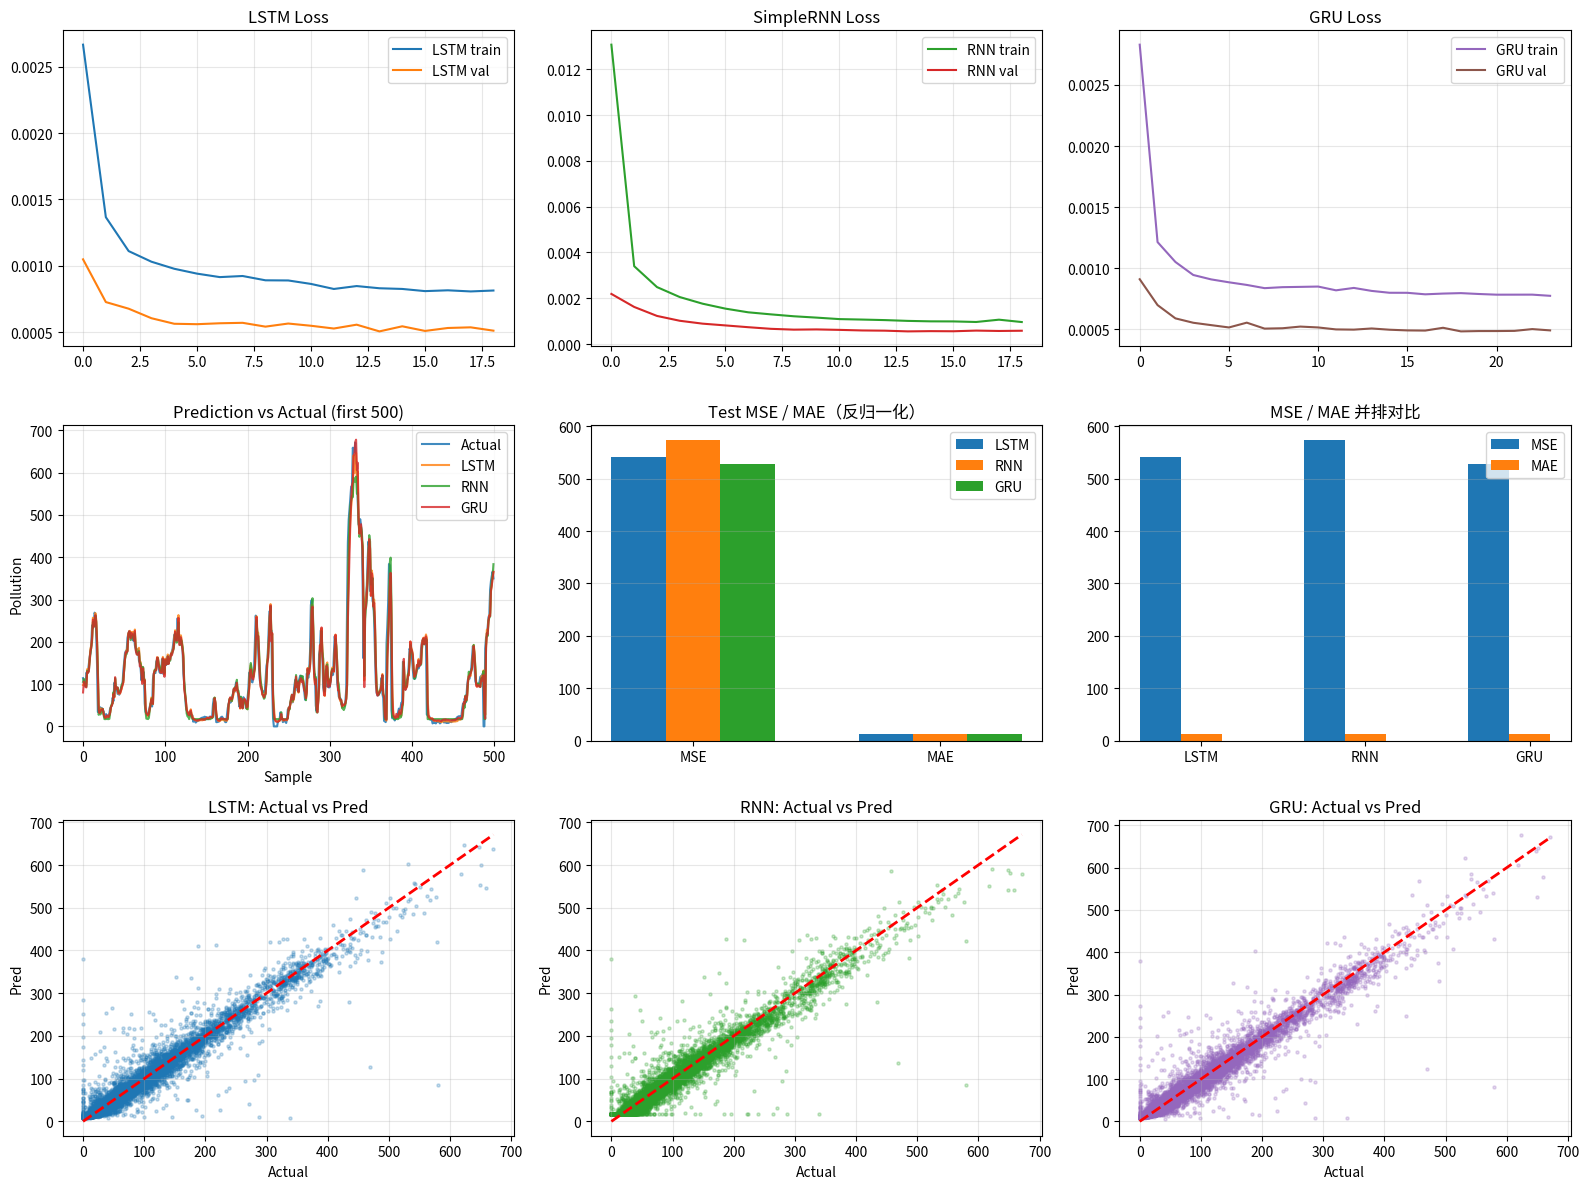

已保存 lstm_results.png, lstm_rnn_gru_comparison.png


In [ ]:
# 8. 可视化结果：LSTM vs RNN vs GRU
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1. 告诉 Matplotlib 你的字体文件在哪里
font_path = '/home/hxy/font.otf'
fm.fontManager.addfont(font_path)

# 2. 获取这个字体的正式名称（它可能叫 "Source Han Sans SC" 之类的）
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

# 3. 设置全局默认字体
plt.rcParams['font.sans-serif'] = [font_name] # 动态设置为你下载的字体名称
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

axes[0, 0].plot(history.history["loss"], label="LSTM train")
axes[0, 0].plot(history.history["val_loss"], label="LSTM val")
axes[0, 0].set_title("LSTM Loss")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history_rnn.history["loss"], label="RNN train", color="C2")
axes[0, 1].plot(history_rnn.history["val_loss"], label="RNN val", color="C3")
axes[0, 1].set_title("SimpleRNN Loss")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(history_gru.history["loss"], label="GRU train", color="C4")
axes[0, 2].plot(history_gru.history["val_loss"], label="GRU val", color="C5")
axes[0, 2].set_title("GRU Loss")
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

plot_len = 500
axes[1, 0].plot(y_test_inv[:plot_len], label="Actual", alpha=0.85)
axes[1, 0].plot(y_pred_inv[:plot_len], label="LSTM", alpha=0.8)
axes[1, 0].plot(y_pred_rnn_inv[:plot_len], label="RNN", alpha=0.8)
axes[1, 0].plot(y_pred_gru_inv[:plot_len], label="GRU", alpha=0.8)
axes[1, 0].set_title(f"Prediction vs Actual (first {plot_len})")
axes[1, 0].set_xlabel("Sample")
axes[1, 0].set_ylabel("Pollution")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

x = np.arange(2)
w = 0.22
axes[1, 1].bar(x - w, [lstm_mse, lstm_mae], w, label="LSTM")
axes[1, 1].bar(x, [mse_rnn, mae_rnn], w, label="RNN")
axes[1, 1].bar(x + w, [mse_gru, mae_gru], w, label="GRU")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(["MSE", "MAE"])
axes[1, 1].set_title("Test MSE / MAE（反归一化）")
axes[1, 1].legend()
axes[1, 1].grid(True, axis="y", alpha=0.3)

axes[1, 2].bar(
    np.arange(3) - 0.25,
    [lstm_mse, mse_rnn, mse_gru],
    0.25,
    label="MSE",
)
axes[1, 2].bar(np.arange(3), [lstm_mae, mae_rnn, mae_gru], 0.25, label="MAE")
axes[1, 2].set_xticks(np.arange(3))
axes[1, 2].set_xticklabels(["LSTM", "RNN", "GRU"])
axes[1, 2].set_title("MSE / MAE 并排对比")
axes[1, 2].legend()
axes[1, 2].grid(True, axis="y", alpha=0.3)

axes[2, 0].scatter(y_test_inv, y_pred_inv, alpha=0.25, s=5)
axes[2, 0].plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    "r--",
    lw=2,
)
axes[2, 0].set_title("LSTM: Actual vs Pred")
axes[2, 0].set_xlabel("Actual")
axes[2, 0].set_ylabel("Pred")
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].scatter(y_test_inv, y_pred_rnn_inv, alpha=0.25, s=5, color="C2")
axes[2, 1].plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    "r--",
    lw=2,
)
axes[2, 1].set_title("RNN: Actual vs Pred")
axes[2, 1].set_xlabel("Actual")
axes[2, 1].set_ylabel("Pred")
axes[2, 1].grid(True, alpha=0.3)

axes[2, 2].scatter(y_test_inv, y_pred_gru_inv, alpha=0.25, s=5, color="C4")
axes[2, 2].plot(
    [y_test_inv.min(), y_test_inv.max()],
    [y_test_inv.min(), y_test_inv.max()],
    "r--",
    lw=2,
)
axes[2, 2].set_title("GRU: Actual vs Pred")
axes[2, 2].set_xlabel("Actual")
axes[2, 2].set_ylabel("Pred")
axes[2, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lstm_results.png", dpi=150)
plt.savefig("lstm_rnn_gru_comparison.png", dpi=150)
plt.show()
print("已保存 lstm_results.png, lstm_rnn_gru_comparison.png")


In [35]:
# 9. 保存模型
import tensorflow as tf

with tf.device("/CPU:0"):
    model.save("lstm_pollution_model.h5")
    model_rnn.save("rnn_pollution_model.h5")
    model_gru.save("gru_pollution_model.h5")
print("模型已保存: lstm_pollution_model.h5, rnn_pollution_model.h5, gru_pollution_model.h5")

# 10. 总结
print("\n" + "=" * 60)
print("多变量时序预测：LSTM vs RNN vs GRU 总结")
print("=" * 60)
print(
    f"""
数据集: LSTM-Multivariate_pollution.csv
样本数量: {len(df)} 条记录
特征数量: {n_features} 个
序列长度: {seq_length} (一周的小时数据)

LSTM 架构:
- LSTM层1: 64 units, return_sequences=True
- Dropout: 0.2
- LSTM层2: 32 units
- Dropout: 0.2
- Dense层: 16 units (ReLU)
- 输出层: 1 unit

RNN 架构（SimpleRNN，全序列 BPTT）:
- SimpleRNN: 64 units, return_sequences=True
- Dropout: 0.2
- SimpleRNN: 32 units
- 其后与 LSTM 相同 Dense 头

GRU 架构:
- GRU: 64 units, return_sequences=True
- Dropout: 0.2
- GRU: 32 units
- 其后与 LSTM 相同 Dense 头

训练（各自最后一 epoch 记录）:
- LSTM 训练损失: {history.history["loss"][-1]:.6f}
- LSTM 验证损失: {history.history["val_loss"][-1]:.6f}
- RNN 训练损失: {history_rnn.history["loss"][-1]:.6f}
- RNN 验证损失: {history_rnn.history["val_loss"][-1]:.6f}
- GRU 训练损失: {history_gru.history["loss"][-1]:.6f}
- GRU 验证损失: {history_gru.history["val_loss"][-1]:.6f}

测试集（反归一化）:
- LSTM  MSE={lstm_mse:.4f}  MAE={lstm_mae:.4f}  R²={lstm_r2:.4f}
- RNN    MSE={mse_rnn:.4f}  MAE={mae_rnn:.4f}  R²={r2_rnn:.4f}
- GRU    MSE={mse_gru:.4f}  MAE={mae_gru:.4f}  R²={r2_gru:.4f}

门控可视化: lstm_gates_visualization.png（第一层 LSTM）
"""
)


模型已保存: lstm_pollution_model.h5, rnn_pollution_model.h5, gru_pollution_model.h5

多变量时序预测：LSTM vs RNN vs GRU 总结

数据集: LSTM-Multivariate_pollution.csv
样本数量: 43800 条记录
特征数量: 8 个
序列长度: 168 (一周的小时数据)

LSTM 架构:
- LSTM层1: 64 units, return_sequences=True
- Dropout: 0.2
- LSTM层2: 32 units
- Dropout: 0.2
- Dense层: 16 units (ReLU)
- 输出层: 1 unit

RNN 架构（SimpleRNN，全序列 BPTT）:
- SimpleRNN: 64 units, return_sequences=True
- Dropout: 0.2
- SimpleRNN: 32 units
- 其后与 LSTM 相同 Dense 头

GRU 架构:
- GRU: 64 units, return_sequences=True
- Dropout: 0.2
- GRU: 32 units
- 其后与 LSTM 相同 Dense 头

训练（各自最后一 epoch 记录）:
- LSTM 训练损失: 0.000814
- LSTM 验证损失: 0.000511
- RNN 训练损失: 0.000961
- RNN 验证损失: 0.000581
- GRU 训练损失: 0.000774
- GRU 验证损失: 0.000491

测试集（反归一化）:
- LSTM  MSE=541.4547  MAE=12.3049  R²=0.9383
- RNN    MSE=573.1438  MAE=13.3843  R²=0.9347
- GRU    MSE=528.7981  MAE=12.2503  R²=0.9397

门控可视化: lstm_gates_visualization.png（第一层 LSTM）

